# 02 — HydroGEN Prior EDA

Explore the Ma 2025 HydroGEN water-table-depth (WTD) prior and its relationship to NWIS well observations for the PNW pilot (WA + OR).

**Questions answered here**
1. Does the HydroGEN prior have systematic bias vs. observed WTD across WA+OR?
2. What is the spatial pattern of the residuals `obs − prior`? — sets expectations for the EDK correction.
3. Does the Ma 2025 uncertainty raster track actual error magnitude (IQR vs σ question)?
4. What variogram structure do the residuals show? (feeds variogram params into EDK)
5. Where is the prior unreliable (steep terrain, coast, irrigated valleys)?

**Dependencies** — run these first  
```bash
make pilot-qc       # produces nwis_sites_clean.parquet, nwis_gwlevels_monthly.parquet
make dem            # produces merit_hydro_1km_5070.tif
make pilot-grid     # produces bbox_grid_1km.nc
make hydrogen       # produces hydrogen_wtd_prior_1km.tif, hydrogen_wtd_uncertainty_1km.tif
```

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.crs import CRS
import xarray as xr
import skgstat as skg

# ── paths ──────────────────────────────────────────────────────────────────
REPO = Path().resolve().parent
DATA = REPO / "data"
PROC = DATA / "processed"
FIG_DIR = REPO / "notebooks" / "figures"
FIG_DIR.mkdir(exist_ok=True)

# ── pilot scope ────────────────────────────────────────────────────────────
PILOT_STATES = ["WA", "OR"]

# PNW_XLIM / PNW_YLIM are computed dynamically in the data-loading cell.

print("REPO:", REPO)
print("PROC:", PROC)

REPO: /Users/marinedenolle/GitHub/gwl-space-time-smooth
PROC: /Users/marinedenolle/GitHub/gwl-space-time-smooth/data/processed


In [2]:
from pyproj import Transformer

# ── Load NWIS observation data ──────────────────────────────────────────────
sites = pd.read_parquet(PROC / "nwis_sites_clean.parquet")

# Restrict to pilot states
sites_pnw = sites.loc[sites["state"].isin(PILOT_STATES)].copy()

# Project lat/lon → EPSG:5070 for spatial operations
transformer = Transformer.from_crs("EPSG:4326", "EPSG:5070", always_xy=True)
sites_pnw["x_m"], sites_pnw["y_m"] = transformer.transform(
    sites_pnw["lon"].values, sites_pnw["lat"].values
)

# Derive land-surface altitude: alt_va_m = WTE + DTW  (by definition of both variables)
sites_pnw["alt_va_m"] = sites_pnw["median_wte_m"] + sites_pnw["median_dtw_m"]

# Rename per-site medians to short names used throughout the notebook
obs = sites_pnw.rename(columns={
    "median_dtw_m": "dtw_m",
    "median_wte_m": "wte_m",
}).copy()

# Total site-months count (for display only)
monthly = pd.read_parquet(PROC / "nwis_gwlevels_monthly.parquet")
monthly_pnw = monthly.loc[monthly["site_no"].isin(obs["site_no"])]

print(f"Sites: {len(obs):,} | site-months: {len(monthly_pnw):,}")
obs[["site_no", "x_m", "y_m", "alt_va_m", "dtw_m", "wte_m"]].head()

# ── Axis limits: derived from actual well locations ────────────────────────────────
_pad = 50_000  # 50 km padding
PNW_XLIM = (float(obs["x_m"].min()) - _pad, float(obs["x_m"].max()) + _pad)
PNW_YLIM = (float(obs["y_m"].min()) - _pad, float(obs["y_m"].max()) + _pad)


Sites: 863 | site-months: 28,832


,site_no,x_m,y_m,alt_va_m,dtw_m,wte_m
0,420013121531801,-2.103474e+06,2.399599e+06,1279.85520,34.043112,1245.812088
1,420030121140401,-2.051495e+06,2.385824e+06,1285.70736,23.906988,1261.800372
2,420120121355401,-2.079924e+06,2.395230e+06,1240.84080,4.136136,1236.704664
3,420125121360601,-2.080076e+06,2.395442e+06,1239.92640,22.320504,1217.605896
4,420126121360201,-2.080069e+06,2.395446e+06,1240.74936,18.438876,1222.310484


In [3]:
# ── Load HydroGEN aligned rasters ──────────────────────────────────────────
def read_band(path: Path) -> tuple[np.ndarray, rasterio.transform.Affine]:
    """Return (arr_float32, transform); nodata → NaN."""
    with rasterio.open(path) as src:
        arr = src.read(1, out_dtype="float32")
        nd = src.nodata if src.nodata is not None else -9999.0
        transform = src.transform
    arr[arr == nd] = np.nan
    return arr, transform

H_DTW_PATH = PROC / "hydrogen_wtd_prior_1km.tif"
H_UNC_PATH = PROC / "hydrogen_wtd_uncertainty_1km.tif"

# ── Warn if not yet generated ───────────────────────────────────────────────
for p in [H_DTW_PATH, H_UNC_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Run `make hydrogen` first: {p}")

h_dtw, transform = read_band(H_DTW_PATH)
h_unc, _         = read_band(H_UNC_PATH)

print(f"HydroGEN DTW grid: {h_dtw.shape}, resolution: {transform.a:.0f} m")
print(f"DTW range:  [{np.nanmin(h_dtw):.1f}, {np.nanmax(h_dtw):.1f}] m")
print(f"Unc range:  [{np.nanmin(h_unc):.1f}, {np.nanmax(h_unc):.1f}] m")
# ── Raster-footprint limits (for DTW/uncertainty maps) ────────────────────────
_pad_r = 50_000
_rows_v, _cols_v = np.where(np.isfinite(h_dtw))
H_XLIM = (
    transform.c + _cols_v.min() * transform.a - _pad_r,
    transform.c + _cols_v.max() * transform.a + _pad_r,
)
H_YLIM = (
    transform.f + _rows_v.max() * transform.e - _pad_r,  # e is negative
    transform.f + _rows_v.min() * transform.e + _pad_r,
)


HydroGEN DTW grid: (1100, 900), resolution: 1000 m
DTW range:  [0.0, 74.3] m
Unc range:  [0.0, 69.0] m


In [4]:
# ── Sample rasters at well locations ──────────────────────────────────────
def sample_raster(arr: np.ndarray, transform: rasterio.transform.Affine,
                  x_m: np.ndarray, y_m: np.ndarray) -> np.ndarray:
    """Nearest-neighbour lookup of arr at projected coords (x_m, y_m)."""
    # (col, row) from (x, y)
    cols = np.floor((x_m - transform.c) / transform.a).astype(int)
    rows = np.floor((y_m - transform.f) / transform.e).astype(int)  # e is negative
    nrows, ncols = arr.shape
    valid = (rows >= 0) & (rows < nrows) & (cols >= 0) & (cols < ncols)
    out = np.full(len(x_m), np.nan, dtype=np.float32)
    out[valid] = arr[rows[valid], cols[valid]]
    return out

x = obs["x_m"].values
y = obs["y_m"].values

obs["h_dtw_m"]  = sample_raster(h_dtw, transform, x, y)   # HydroGEN DTW at well
obs["h_unc_m"]  = sample_raster(h_unc,  transform, x, y)   # HydroGEN uncertainty at well

# HydroGEN WTE = DEM - HydroGEN_DTW  (DEM is land-surface altitude of the site)
obs["h_wte_m"] = obs["alt_va_m"] - obs["h_dtw_m"]

# Residuals
obs["residual_wte_m"] = obs["wte_m"] - obs["h_wte_m"]   # obs − prior in WTE space
obs["residual_dtw_m"] = obs["dtw_m"] - obs["h_dtw_m"]   # obs − prior in DTW space

obs_valid = obs.dropna(subset=["h_dtw_m", "wte_m"])
print(f"Wells with valid HydroGEN overlap: {len(obs_valid):,} / {len(obs):,}")

n_outside = obs["h_dtw_m"].isna().sum()
if n_outside:
    print(f"  ⚠  {n_outside} wells outside HydroGEN raster extent")

Wells with valid HydroGEN overlap: 351 / 863
  ⚠  512 wells outside HydroGEN raster extent


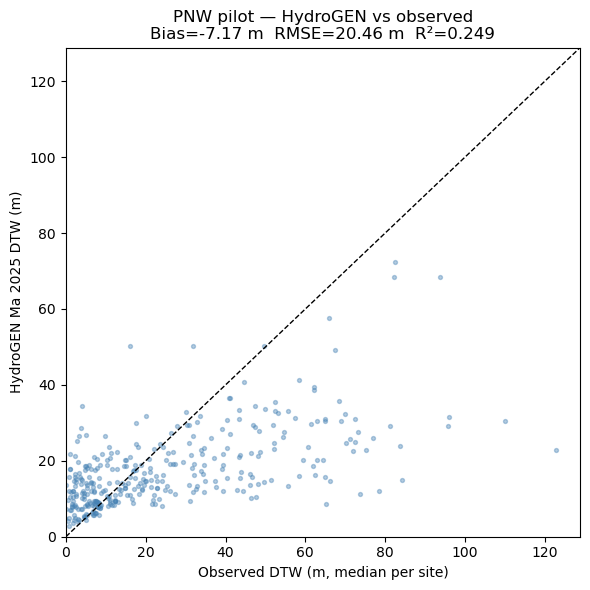

Bias (prior − obs): -7.166 m
RMSE:               20.462 m
R²:                 0.249


In [5]:
# ── 1. Bias & skill: scatter obs DTW vs HydroGEN DTW ─────────────────────
from sklearn.metrics import mean_squared_error, r2_score

y_obs  = obs_valid["dtw_m"].values
y_pred = obs_valid["h_dtw_m"].values
mask   = np.isfinite(y_obs) & np.isfinite(y_pred)

bias  = np.mean(y_pred[mask] - y_obs[mask])
rmse  = np.sqrt(mean_squared_error(y_obs[mask], y_pred[mask]))
r2    = r2_score(y_obs[mask], y_pred[mask])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_obs[mask], y_pred[mask], s=8, alpha=0.4, color="steelblue", rasterized=True)
lims = (0, max(y_obs[mask].max(), y_pred[mask].max()) * 1.05)
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Observed DTW (m, median per site)")
ax.set_ylabel("HydroGEN Ma 2025 DTW (m)")
ax.set_title(f"PNW pilot — HydroGEN vs observed\nBias={bias:+.2f} m  RMSE={rmse:.2f} m  R²={r2:.3f}")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_scatter_obs_vs_prior.png", dpi=150)
plt.show()

print(f"Bias (prior − obs): {bias:+.3f} m")
print(f"RMSE:               {rmse:.3f} m")
print(f"R²:                 {r2:.3f}")

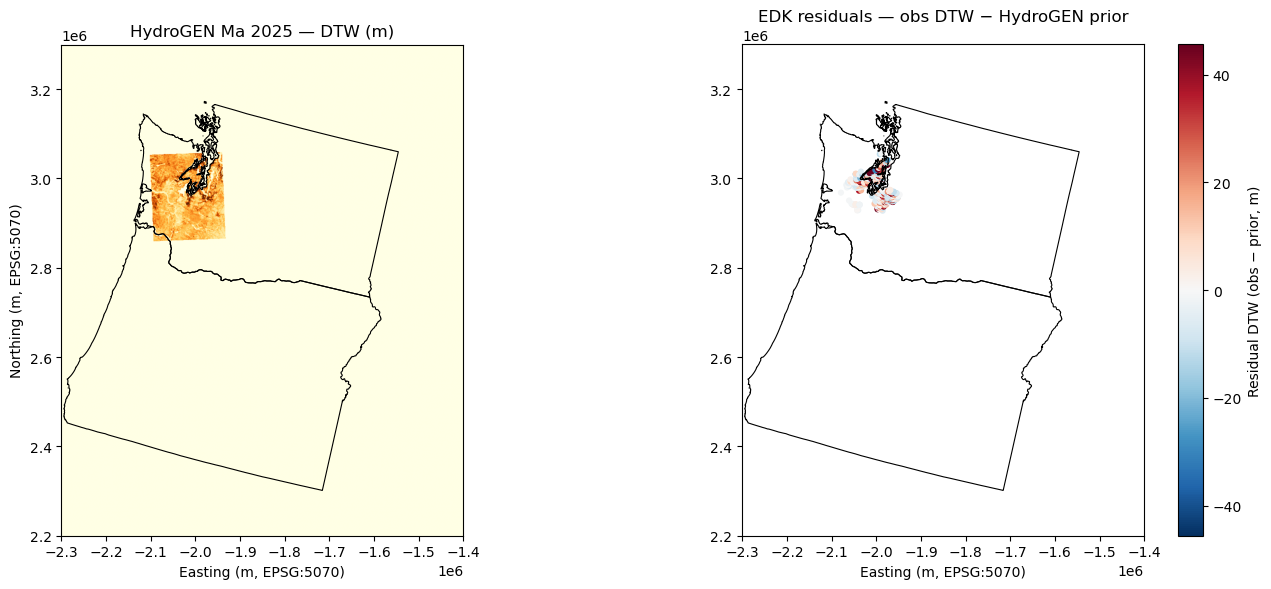

In [6]:
# ── 2. Map of HydroGEN DTW and NWIS well residuals ─────────────────────────
# Load state boundaries for context
try:
    pnw = gpd.read_file(
        "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_500k.zip"
    ).to_crs(epsg=5070)
    pnw = pnw[pnw["STUSPS"].isin(PILOT_STATES)]
except Exception as exc:
    pnw = None
    print(f"State boundaries unavailable (offline?): {exc}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -- Left: HydroGEN DTW raster --
ax = axes[0]
with rasterio.open(H_DTW_PATH) as src:
    from rasterio.plot import show as rshow
    rshow(src.read(1), transform=src.transform, ax=ax, cmap="YlOrBr", vmin=0, vmax=30)
if pnw is not None:
    pnw.boundary.plot(ax=ax, color="black", linewidth=0.8)
ax.set_xlim(H_XLIM); ax.set_ylim(H_YLIM)
ax.set_title("HydroGEN Ma 2025 — DTW (m)")
ax.set_xlabel("Easting (m, EPSG:5070)")
ax.set_ylabel("Northing (m, EPSG:5070)")

# -- Right: residual (obs − prior) at well locations --
ax = axes[1]
res = obs_valid["residual_dtw_m"].values
vmax_res = np.nanpercentile(np.abs(res), 95)
sc = ax.scatter(
    obs_valid["x_m"], obs_valid["y_m"],
    c=res, cmap="RdBu_r", vmin=-vmax_res, vmax=vmax_res,
    s=20, edgecolors="none", rasterized=True,
)
if pnw is not None:
    pnw.boundary.plot(ax=ax, color="black", linewidth=0.8)
plt.colorbar(sc, ax=ax, label="Residual DTW (obs − prior, m)")
ax.set_xlim(PNW_XLIM); ax.set_ylim(PNW_YLIM)
ax.set_title("EDK residuals — obs DTW − HydroGEN prior")
ax.set_xlabel("Easting (m, EPSG:5070)")
ax.set_aspect("equal")

fig.tight_layout()
fig.savefig(FIG_DIR / "02_map_prior_and_residuals.png", dpi=150)
plt.show()

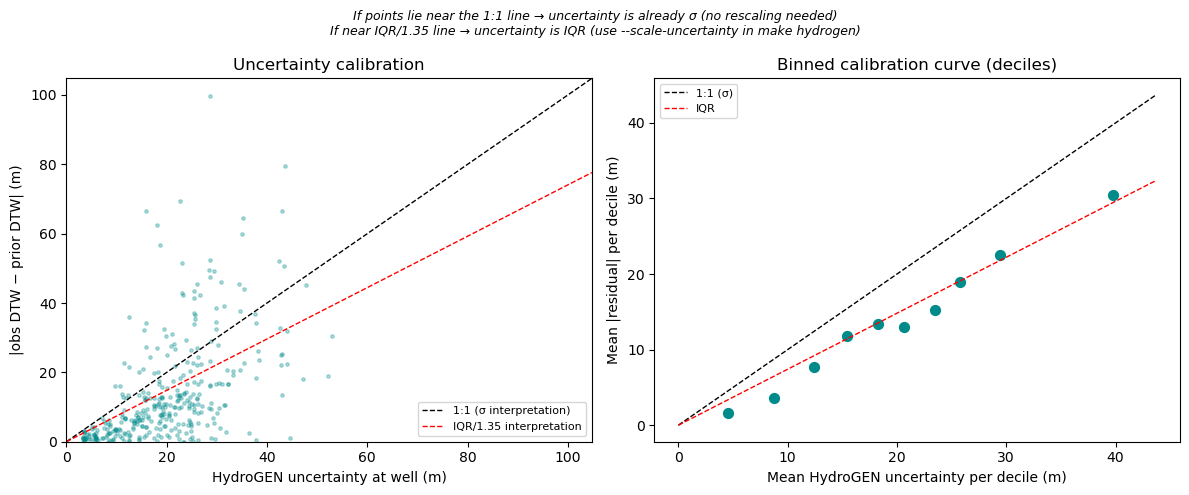

Median |residual| / HydroGEN uncertainty = 0.507
  → 1.0  suggests σ interpretation is correct
  → 0.74 (≈1/1.35) suggests IQR interpretation (set --scale-uncertainty)


In [7]:
# ── 3. Does HydroGEN uncertainty track actual error magnitude? ─────────────
# If uncertainty is IQR, it should be ~1.35x σ; if σ, it should correlate 1:1
# with |residual|. We test both.

abs_res = np.abs(obs_valid["residual_dtw_m"].values)
h_unc_at_wells = obs_valid["h_unc_m"].values
valid = np.isfinite(abs_res) & np.isfinite(h_unc_at_wells)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: |residual| vs HydroGEN uncertainty
ax = axes[0]
ax.scatter(h_unc_at_wells[valid], abs_res[valid], s=6, alpha=0.3, color="darkcyan")
lim = max(h_unc_at_wells[valid].max(), abs_res[valid].max()) * 1.05
ax.plot([0, lim], [0, lim],       "k--", lw=1, label="1:1 (σ interpretation)")
ax.plot([0, lim], [0, lim/1.35],  "r--", lw=1, label="IQR/1.35 interpretation")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("HydroGEN uncertainty at well (m)")
ax.set_ylabel("|obs DTW − prior DTW| (m)")
ax.set_title("Uncertainty calibration")
ax.legend(fontsize=8)

# Binned: mean |residual| per uncertainty decile
ax = axes[1]
try:
    q_labels = pd.qcut(h_unc_at_wells[valid], q=10, duplicates="drop")
    df_bin = pd.DataFrame({"unc": h_unc_at_wells[valid], "abs_res": abs_res[valid], "q": q_labels})
    grouped = df_bin.groupby("q", observed=True).agg(mean_unc=("unc", "mean"), mean_abs_res=("abs_res", "mean"))
    ax.scatter(grouped["mean_unc"], grouped["mean_abs_res"], s=50, color="darkcyan")
    lim2 = max(grouped["mean_unc"].max(), grouped["mean_abs_res"].max()) * 1.1
    ax.plot([0, lim2], [0, lim2],       "k--", lw=1, label="1:1 (σ)")
    ax.plot([0, lim2], [0, lim2/1.35],  "r--", lw=1, label="IQR")
    ax.set_xlabel("Mean HydroGEN uncertainty per decile (m)")
    ax.set_ylabel("Mean |residual| per decile (m)")
    ax.set_title("Binned calibration curve (deciles)")
    ax.legend(fontsize=8)
except Exception as e:
    ax.set_title(f"Binning failed: {e}")

fig.suptitle(
    "If points lie near the 1:1 line → uncertainty is already σ (no rescaling needed)\n"
    "If near IQR/1.35 line → uncertainty is IQR (use --scale-uncertainty in make hydrogen)",
    fontsize=9, style="italic"
)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_uncertainty_calibration.png", dpi=150)
plt.show()

# Quantitative answer
ratio = np.nanmedian(abs_res[valid] / h_unc_at_wells[valid])
print(f"Median |residual| / HydroGEN uncertainty = {ratio:.3f}")
print(f"  → 1.0  suggests σ interpretation is correct")
print(f"  → 0.74 (≈1/1.35) suggests IQR interpretation (set --scale-uncertainty)")

Using 350 / 351 residual points for variogram (outliers removed)


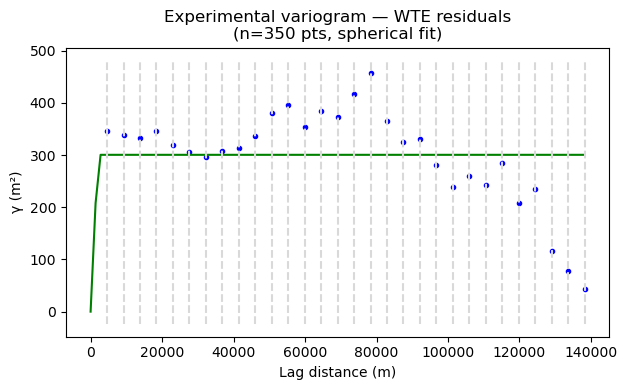

Spherical variogram fit:
  Nugget:  0.0000 m²
  Sill:    300.5544 m²
  Range:   2.8 km


In [8]:
# ── 4. Variogram of EDK residuals ──────────────────────────────────────────
# Fit an experimental variogram to the WTE residuals.  This sets realistic
# range/sill expectations for the kriging step in interpolate_baseline.

res_wte = obs_valid["residual_wte_m"].values
x_res   = obs_valid["x_m"].values
y_res   = obs_valid["y_m"].values

# Filter out extreme outliers (> 3× IQR) to avoid variogram distortion
q25, q75 = np.percentile(res_wte[np.isfinite(res_wte)], [25, 75])
iqr_res  = q75 - q25
inlier   = np.isfinite(res_wte) & (res_wte > q25 - 3 * iqr_res) & (res_wte < q75 + 3 * iqr_res)

print(f"Using {inlier.sum():,} / {len(res_wte):,} residual points for variogram (outliers removed)")

# Subsample if very large (skgstat exhausts memory above ~5000 pairs)
MAX_VARIO_PTS = 2000
idx = np.where(inlier)[0]
if len(idx) > MAX_VARIO_PTS:
    rng_vario = np.random.default_rng(42)
    idx = rng_vario.choice(idx, MAX_VARIO_PTS, replace=False)

coords = np.column_stack([x_res[idx], y_res[idx]])
values = res_wte[idx]

try:
    V = skg.Variogram(coords, values, model="spherical", n_lags=30, maxlag=400_000)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    V.plot(axes=axes[0])
    axes[0].set_title(f"Experimental variogram — WTE residuals\n(n={len(idx):,} pts, spherical fit)")
    axes[0].set_xlabel("Lag distance (m)")
    axes[0].set_ylabel("γ (m²)")

    # Anisotropy rose (directional variograms in 4 directions)
    try:
        V_dir = skg.DirectionalVariogram(
            coords, values, model="spherical", n_lags=20,
            maxlag=400_000, azimuth=0, tolerance=45
        )
        V_dir.plot(axes=axes[1])
        axes[1].set_title("Directional variogram (N–S, E–W)")
    except Exception:
        axes[1].set_visible(False)

    fig.tight_layout()
    fig.savefig(FIG_DIR / "02_variogram_residuals.png", dpi=150)
    plt.show()

    # Extract fitted params — use V.describe() for named values (skgstat ≥1.0)
    params = V.describe()
    nugget = params.get("nugget", 0.0)
    sill   = params.get("sill",   params.get("normalized_sill", float("nan")))
    rng_km = params.get("effective_range", float("nan"))
    print(f"Spherical variogram fit:")
    print(f"  Nugget:  {nugget:.4f} m²")
    print(f"  Sill:    {sill:.4f} m²")
    print(f"  Range:   {rng_km/1000:.1f} km")

except Exception as exc:
    print(f"Variogram fitting failed: {exc}")
    print("This may be OK if there are too few points after outlier removal.")

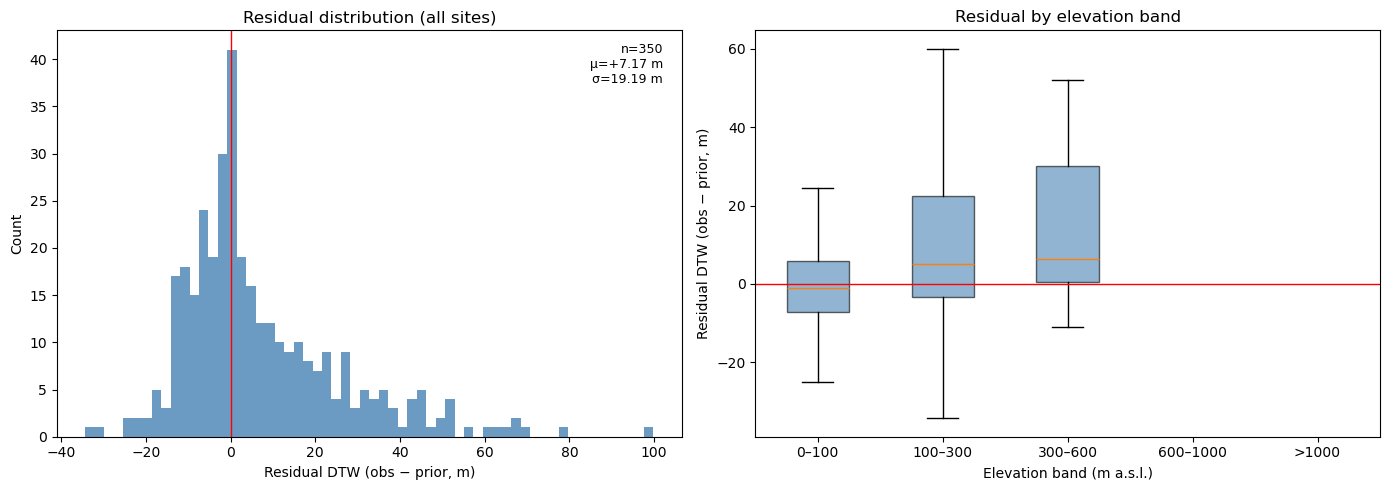

           count   mean    std
elev_band                     
0–100        154   1.84  14.77
100–300      191  11.22  21.12
300–600        6  15.05  24.24


In [9]:
# ── 5. Residual distribution: overall + by elevation band ──────────────────
# HydroGEN is known to be less reliable in steep mountain terrain and
# irrigated lowlands. Check if residuals differ systematically.

obs_valid_e = obs_valid.copy()
elev_bins   = [0, 100, 300, 600, 1000, 3500]
elev_labels = ["0–100", "100–300", "300–600", "600–1000", ">1000"]
obs_valid_e["elev_band"] = pd.cut(
    obs_valid_e["alt_va_m"], bins=elev_bins, labels=elev_labels
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall histogram
ax = axes[0]
ax.hist(obs_valid_e["residual_dtw_m"].dropna(), bins=60, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(0, color="red", lw=1)
ax.set_xlabel("Residual DTW (obs − prior, m)")
ax.set_ylabel("Count")
ax.set_title("Residual distribution (all sites)")
stats_txt = (
    f"n={inlier.sum():,}\n"
    f"μ={obs_valid_e['residual_dtw_m'].mean():+.2f} m\n"
    f"σ={obs_valid_e['residual_dtw_m'].std():.2f} m"
)
ax.text(0.97, 0.97, stats_txt, ha="right", va="top", transform=ax.transAxes, fontsize=9)

# Box-plots by elevation band
ax = axes[1]
groups = [
    obs_valid_e.loc[obs_valid_e["elev_band"] == lab, "residual_dtw_m"].dropna().values
    for lab in elev_labels
]
bp = ax.boxplot(groups, tick_labels=elev_labels, showfliers=False, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)
ax.axhline(0, color="red", lw=1)
ax.set_xlabel("Elevation band (m a.s.l.)")
ax.set_ylabel("Residual DTW (obs − prior, m)")
ax.set_title("Residual by elevation band")

fig.tight_layout()
fig.savefig(FIG_DIR / "02_residual_distribution.png", dpi=150)
plt.show()

# tabulate
print(obs_valid_e.groupby("elev_band", observed=True)["residual_dtw_m"].agg(["count", "mean", "std"]).round(2))

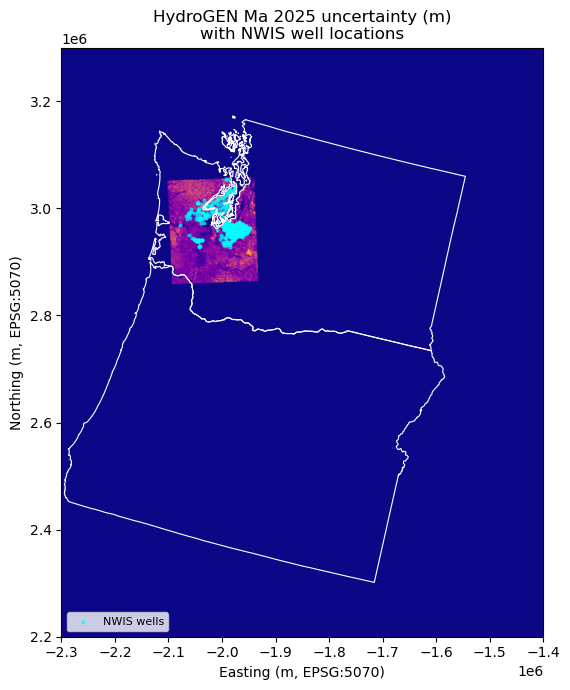

In [10]:
# ── 6. HydroGEN uncertainty spatial map ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

with rasterio.open(H_UNC_PATH) as src:
    from rasterio.plot import show as rshow
    img = rshow(src.read(1), transform=src.transform, ax=ax, cmap="plasma", vmin=0)

if pnw is not None:
    pnw.boundary.plot(ax=ax, color="white", linewidth=0.8)

ax.scatter(
    obs_valid["x_m"], obs_valid["y_m"],
    c="cyan", s=4, alpha=0.6, label="NWIS wells",
)
ax.set_xlim(PNW_XLIM); ax.set_ylim(PNW_YLIM)
ax.set_title("HydroGEN Ma 2025 uncertainty (m)\nwith NWIS well locations")
ax.set_xlabel("Easting (m, EPSG:5070)")
ax.set_ylabel("Northing (m, EPSG:5070)")
ax.legend(loc="lower left", fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "02_map_hydrogen_uncertainty.png", dpi=150)
plt.show()

In [11]:
# ── 7. Summary takeaways ───────────────────────────────────────────────────
bias_dtw  = obs_valid["residual_dtw_m"].mean()
rmse_dtw  = np.sqrt((obs_valid["residual_dtw_m"] ** 2).mean())
r2_dtw    = 1 - obs_valid["residual_dtw_m"].var() / obs_valid["dtw_m"].var()
ratio     = np.nanmedian(
    np.abs(obs_valid["residual_dtw_m"].values)
    / obs_valid["h_unc_m"].values
)

print("=" * 55)
print("HydroGEN prior vs NWIS observations — PNW pilot")
print("=" * 55)
print(f"  Sites evaluated : {len(obs_valid):,}")
print(f"  Bias (prior−obs): {bias_dtw:+.2f} m  (positive → prior is deeper)")
print(f"  RMSE            : {rmse_dtw:.2f} m")
print(f"  R²              : {r2_dtw:.3f}")
print(f"  |resid|/unc     : {ratio:.3f}  (1.0=σ, 0.74=IQR)")
print()
unc_interp = "σ (no rescaling needed)" if ratio > 0.9 else "IQR → run `make hydrogen --scale-uncertainty` if rescaling flag available"
print(f"  Uncertainty interpretation: {unc_interp}")
print()
print("See figures/02_*.png for spatial maps and calibration curves.")

HydroGEN prior vs NWIS observations — PNW pilot
  Sites evaluated : 351
  Bias (prior−obs): +7.17 m  (positive → prior is deeper)
  RMSE            : 20.46 m
  R²              : 0.341
  |resid|/unc     : 0.507  (1.0=σ, 0.74=IQR)

  Uncertainty interpretation: IQR → run `make hydrogen --scale-uncertainty` if rescaling flag available

See figures/02_*.png for spatial maps and calibration curves.
